In [ ]:
# E-Commerce Order Analytics

## Advanced EDA and Feature Engineering

### Project 1 — DecodeLabs Data Science Training

This project focuses on transforming raw e-commerce order data into a clean, analysis-ready and machine-learning-ready dataset through:

- Exploratory Data Analysis
- Missing Value Treatment
- Outlier Detection
- Statistical Data Cleaning
- Feature Engineering

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.impute import KNNImputer

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_excel(
    "../data/raw/Dataset for Data Analytics.xlsx"
)

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.shape


(1200, 14)

In [ ]:
### Dataset Dimensions

The dataset contains 1,200 records and 14 columns. Each row represents an e-commerce order.

In [5]:
df.columns.tolist()

['OrderID',
 'Date',
 'CustomerID',
 'Product',
 'Quantity',
 'UnitPrice',
 'ShippingAddress',
 'PaymentMethod',
 'OrderStatus',
 'TrackingNumber',
 'ItemsInCart',
 'CouponCode',
 'ReferralSource',
 'TotalPrice']

In [6]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [7]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [8]:
df.sample(5)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1109,ORD201109,2024-04-08,C62277,Printer,4,77.47,474 Main St,Gift Card,Returned,TRK32026174,7,SAVE10,Instagram,309.88
260,ORD200260,2023-05-17,C12245,Monitor,2,407.79,153 Main St,Debit Card,Shipped,TRK22000463,3,NaN,Google,815.58
1107,ORD201107,2025-06-30,C25110,Tablet,2,63.21,282 Main St,Online,Cancelled,TRK80963328,4,SAVE10,Google,126.42
231,ORD200231,2023-11-05,C30955,Phone,4,41.90,327 Main St,Gift Card,Pending,TRK46898848,9,FREESHIP,Instagram,167.60


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [10]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [11]:
df.describe(include="object")

,OrderID,CustomerID,Product,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200,891,1200
unique,1200,1189,7,655,5,5,1200,3,5
top,ORD200000,C98474,Printer,533 Main St,Online,Cancelled,TRK37947903,FREESHIP,Instagram
freq,1,2,181,8,258,250,1,313,259


In [12]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
CouponCode,309,25.75
OrderID,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
Date,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
OrderStatus,0,0.00
PaymentMethod,0,0.00


In [13]:
duplicate_count = df.duplicated().sum()

print(
    f"Number of duplicate rows: {duplicate_count}"
)

Number of duplicate rows: 0


In [14]:
duplicate_order_ids = df["OrderID"].duplicated().sum()

print(
    f"Duplicate OrderIDs: {duplicate_order_ids}"
)

Duplicate OrderIDs: 0


In [15]:
for column in df.select_dtypes(
    include="object"
).columns:

    print(f"\n{column}")
    print(df[column].nunique())
    print(df[column].unique()[:10])


OrderID
1200
<StringArray>
['ORD200000', 'ORD200001', 'ORD200002', 'ORD200003', 'ORD200004', 'ORD200005',
 'ORD200006', 'ORD200007', 'ORD200008', 'ORD200009']
Length: 10, dtype: str

CustomerID
1189
<StringArray>
['C72649', 'C75739', 'C81728', 'C33540', 'C81840', 'C37249', 'C83492',
 'C41460', 'C26817', 'C31946']
Length: 10, dtype: str

Product
7
<StringArray>
['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk']
Length: 7, dtype: str

ShippingAddress
655
<StringArray>
['928 Main St', '823 Main St', '512 Main St', '275 Main St', '668 Main St',
 '934 Main St', '986 Main St', '706 Main St', '904 Main St', '102 Main St']
Length: 10, dtype: str

PaymentMethod
5
<StringArray>
['Debit Card', 'Online', 'Credit Card', 'Gift Card', 'Cash']
Length: 5, dtype: str

OrderStatus
5
<StringArray>
['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending']
Length: 5, dtype: str

TrackingNumber
1200
<StringArray>
['TRK37947903', 'TRK91186779', 'TRK42903982', 'TRK62788070', 'TRK29241424'

In [ ]:
## 4. Data Quality Assessment

This section evaluates the dataset for missing values, duplicate records, inconsistent data types, and potential data quality issues before performing exploratory analysis and feature engineering.

In [2]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

missing_summary = (
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
    .sort_values(
        by="Missing_Count",
        ascending=False
    )
)

missing_summary

NameError: name 'df' is not defined

In [3]:
import pandas as pd

In [5]:
df = pd.read_excel(
    "../data/raw/Dataset for Data Analytics.xlsx"
)

In [6]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [7]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

missing_summary = (
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
    .sort_values(
        by="Missing_Count",
        ascending=False
    )
)

missing_summary

,Missing_Count,Missing_Percentage
CouponCode,309,25.75


In [8]:
df.shape


(1200, 14)

In [9]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_summary = (
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
    .sort_values(
        by="Missing_Count",
        ascending=False
    )
)

missing_summary

,Missing_Count,Missing_Percentage
CouponCode,309,25.75


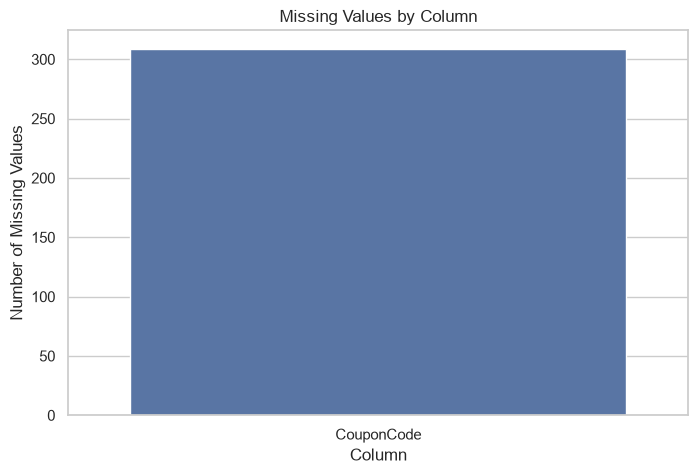

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing_Count"]
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")

plt.show()

In [11]:
duplicate_rows = df.duplicated().sum()

print(
    f"Total duplicate rows: {duplicate_rows}"
)

Total duplicate rows: 0


In [12]:
print(
    "Duplicate OrderIDs:",
    df["OrderID"].duplicated().sum()
)

print(
    "Duplicate TrackingNumbers:",
    df["TrackingNumber"].duplicated().sum()
)

Duplicate OrderIDs: 0
Duplicate TrackingNumbers: 0


In [13]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [14]:
missing_summary

,Missing_Count,Missing_Percentage
CouponCode,309,25.75


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["CouponCode"].value_counts(dropna=False)

CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [17]:
df["CouponCode"].isnull().sum()

np.int64(309)

In [18]:
df["CouponCode"] = df["CouponCode"].fillna("NO_COUPON")

In [19]:
df["CouponCode"].isnull().sum()

np.int64(0)

In [20]:
df["CouponCode"].value_counts()

CouponCode
FREESHIP     313
NO_COUPON    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

In [ ]:
### Missing Value Treatment: CouponCode

The `CouponCode` column contained 309 missing values, representing 25.75% of the dataset. Since `CouponCode` is a categorical variable, mean or median imputation is not appropriate.

The missing values were replaced with `NO_COUPON`. This preserves the information that the order did not have an associated coupon code and also eliminates missing values from the dataset.

In [21]:
print("Duplicate OrderIDs:", df["OrderID"].duplicated().sum())
print("Duplicate CustomerIDs:", df["CustomerID"].duplicated().sum())
print("Duplicate TrackingNumbers:", df["TrackingNumber"].duplicated().sum())

Duplicate OrderIDs: 0
Duplicate CustomerIDs: 11
Duplicate TrackingNumbers: 0


In [22]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [23]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())
print("ItemsInCart < 0:", (df["ItemsInCart"] < 0).sum())
print("TotalPrice <= 0:", (df["TotalPrice"] <= 0).sum())

Quantity <= 0: 0
UnitPrice <= 0: 0
ItemsInCart < 0: 0
TotalPrice <= 0: 0


In [24]:
df["CalculatedTotalPrice"] = (
    df["Quantity"] * df["UnitPrice"]
)

In [25]:
df["PriceDifference"] = (
    df["TotalPrice"] - df["CalculatedTotalPrice"]
)

In [26]:
df[
    [
        "Quantity",
        "UnitPrice",
        "TotalPrice",
        "CalculatedTotalPrice",
        "PriceDifference"
    ]
].head(10)

,Quantity,UnitPrice,TotalPrice,CalculatedTotalPrice,PriceDifference
0,5,570.62,2853.10,2853.10,0.000000e+00
1,2,151.35,302.70,302.70,0.000000e+00
2,5,550.68,2753.40,2753.40,4.547474e-13
3,1,273.19,273.19,273.19,0.000000e+00
4,4,626.01,2504.04,2504.04,0.000000e+00
5,2,245.86,491.72,491.72,0.000000e+00
6,1,664.42,664.42,664.42,0.000000e+00
7,5,149.55,747.75,747.75,0.000000e+00
8,2,134.28,268.56,268.56,0.000000e+00
9,4,509.38,2037.52,2037.52,0.000000e+00


In [27]:
df["PriceDifference"].describe()

count    1.200000e+03
mean     2.475057e-15
std      7.923713e-14
min     -4.547474e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
Name: PriceDifference, dtype: float64

In [28]:
(df["PriceDifference"].abs() < 0.01).mean() * 100

np.float64(100.0)

In [29]:
mismatched_orders = df[
    df["PriceDifference"].abs() >= 0.01
]

mismatched_orders.shape

(0, 16)

In [ ]:
### Business Logic Validation: TotalPrice

The reported `TotalPrice` was validated against the calculated value:

TotalPrice = Quantity × UnitPrice

A tolerance of 0.01 was used to account for minor floating-point rounding differences. No mismatched records were identified, confirming that the `TotalPrice` values are internally consistent with the order quantity and unit price.

In [30]:
df.drop(
    columns=[
        "CalculatedTotalPrice",
        "PriceDifference"
    ],
    inplace=True
)

In [31]:
df.shape

(1200, 14)

In [32]:
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

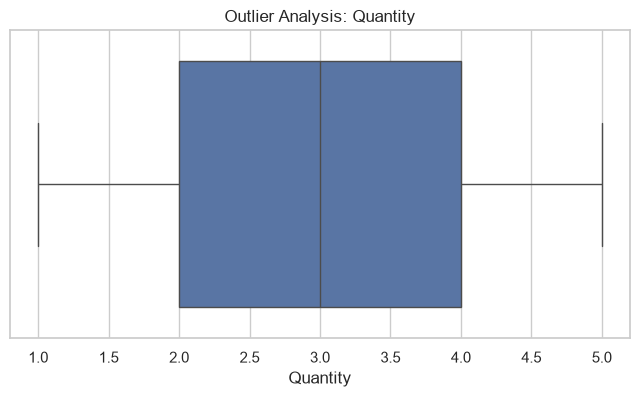

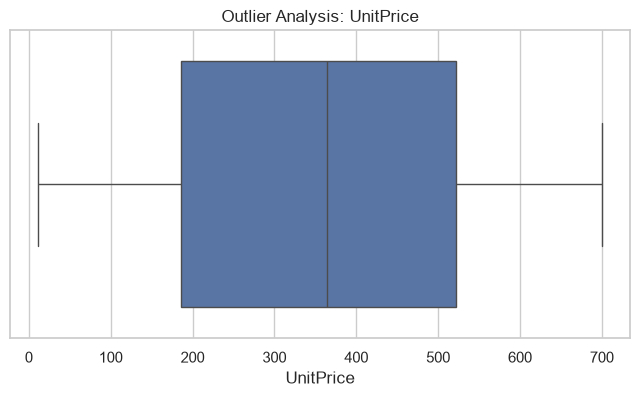

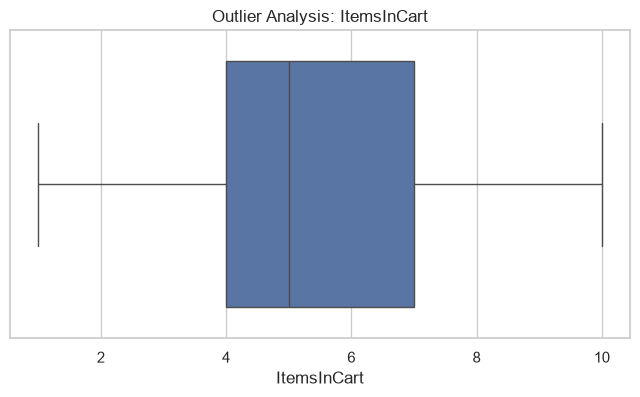

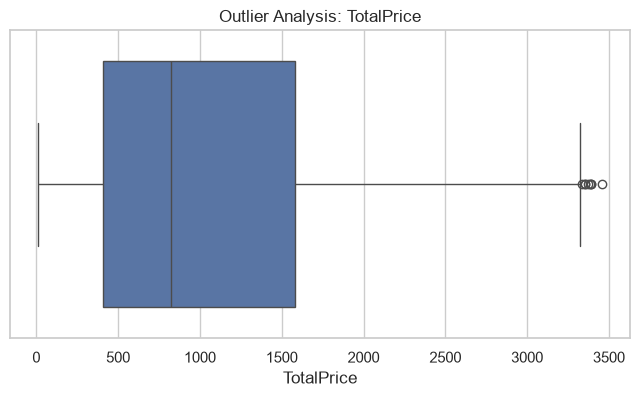

In [33]:
for column in numeric_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(
        f"Outlier Analysis: {column}"
    )

    plt.show()

In [34]:
def detect_outliers_iqr(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return {
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    }

In [35]:
outlier_results = []

for column in numeric_columns:
    result = detect_outliers_iqr(df, column)
    outlier_results.append(result)

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Quantity,2.0000,4.000,2.0000,-1.00000,7.00000,0
1,UnitPrice,186.0625,521.570,335.5075,-317.19875,1024.83125,0
2,ItemsInCart,4.0000,7.000,3.0000,-0.50000,11.50000,0
3,TotalPrice,410.5200,1578.475,1167.9550,-1341.41250,3330.40750,8


In [36]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

totalprice_outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > upper_bound)
]

totalprice_outliers[
    [
        "OrderID",
        "Product",
        "Quantity",
        "UnitPrice",
        "TotalPrice"
    ]
].head(20)

,OrderID,Product,Quantity,UnitPrice,TotalPrice
107,ORD200107,Printer,5,670.75,3353.75
326,ORD200326,Laptop,5,670.48,3352.40
328,ORD200328,Tablet,5,674.04,3370.20
469,ORD200469,Chair,5,676.98,3384.90
632,ORD200632,Laptop,5,678.16,3390.80
789,ORD200789,Tablet,5,691.28,3456.40
1065,ORD201065,Printer,5,666.80,3334.00
1122,ORD201122,Monitor,5,678.19,3390.95


In [37]:
def cap_outliers_iqr(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data[column] = data[column].clip(
        lower_bound,
        upper_bound
    )
    
    return data

In [38]:
df_before_outlier_treatment = df.copy()

In [39]:
for column in numeric_columns:
    df = cap_outliers_iqr(df, column)

In [40]:
comparison = pd.DataFrame({
    "Before": df_before_outlier_treatment[numeric_columns].max(),
    "After": df[numeric_columns].max()
})

comparison

,Before,After
Quantity,5.00,5.0000
UnitPrice,699.93,699.9300
ItemsInCart,10.00,10.0000
TotalPrice,3456.40,3330.4075


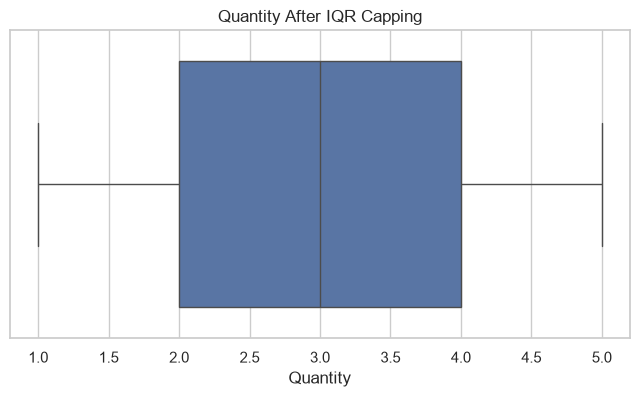

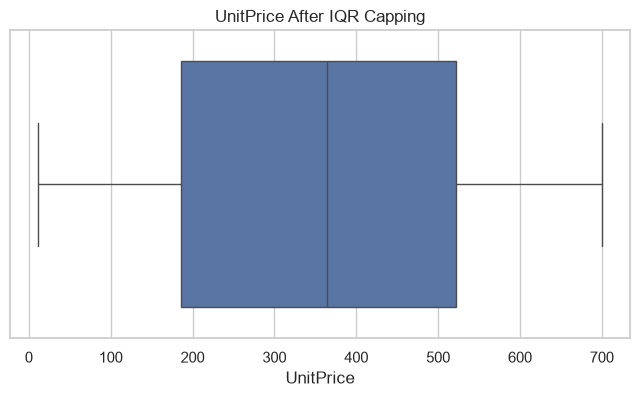

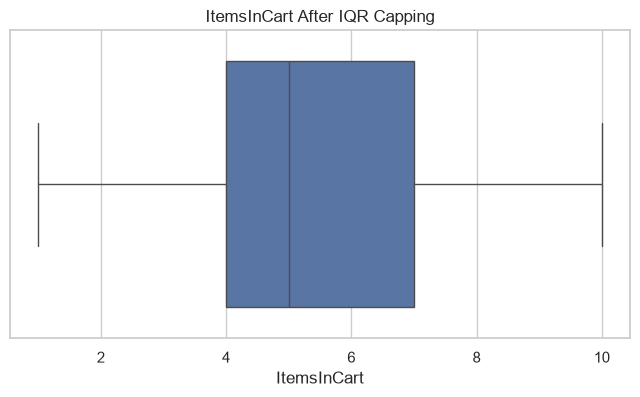

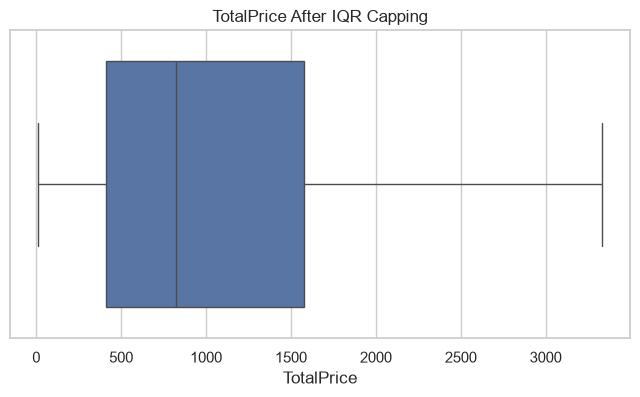

In [41]:
for column in numeric_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(
        f"{column} After IQR Capping"
    )

    plt.show()

In [ ]:
## Outlier Treatment

The Interquartile Range (IQR) method was used to identify statistical outliers in the numerical variables.

Instead of deleting outlier records, IQR-based capping was applied. This approach preserves all valid e-commerce transactions while limiting the influence of extreme values on future statistical analysis and machine-learning models.

The dataset therefore retains all 1,200 observations after outlier treatment.

In [42]:
outlier_summary

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Quantity,2.0000,4.000,2.0000,-1.00000,7.00000,0
1,UnitPrice,186.0625,521.570,335.5075,-317.19875,1024.83125,0
2,ItemsInCart,4.0000,7.000,3.0000,-0.50000,11.50000,0
3,TotalPrice,410.5200,1578.475,1167.9550,-1341.41250,3330.40750,8


In [43]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()
df["DayOfWeek"] = df["Date"].dt.day_name()
df["DayOfMonth"] = df["Date"].dt.day

In [44]:
df[
    [
        "Date",
        "Year",
        "Month",
        "MonthName",
        "DayOfWeek"
    ]
].head()

,Date,Year,Month,MonthName,DayOfWeek
0,2023-01-04,2023,1,January,Wednesday
1,2024-08-23,2024,8,August,Friday
2,2024-02-27,2024,2,February,Tuesday
3,2023-10-15,2023,10,October,Sunday
4,2025-05-08,2025,5,May,Thursday


In [45]:
customer_order_counts = (
    df.groupby("CustomerID")["OrderID"]
    .transform("count")
)

df["CustomerOrderCount"] = customer_order_counts

In [46]:
df["CustomerType"] = np.where(
    df["CustomerOrderCount"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

In [47]:
df["CustomerType"].value_counts()

CustomerType
One-Time Customer    1178
Repeat Customer        22
Name: count, dtype: int64

In [48]:
df["UsedCoupon"] = np.where(
    df["CouponCode"] == "NO_COUPON",
    0,
    1
)

In [49]:
df["UsedCoupon"].value_counts()

UsedCoupon
1    891
0    309
Name: count, dtype: int64

In [50]:
df.shape

(1200, 22)

In [51]:
df.to_csv(
    "../data/processed/ecommerce_cleaned.csv",
    index=False
)

In [ ]:
## Data Dictionary

| Column | Description |
|---|---|
| OrderID | Unique identifier for each order |
| Date | Date on which the order was placed |
| CustomerID | Unique customer identifier |
| Product | Product purchased |
| Quantity | Number of units purchased |
| UnitPrice | Price per unit |
| ShippingAddress | Shipping address associated with the order |
| PaymentMethod | Method used for payment |
| OrderStatus | Current status of the order |
| TrackingNumber | Unique shipment tracking identifier |
| ItemsInCart | Number of items in the customer's cart |
| CouponCode | Coupon applied to the order |
| ReferralSource | Source through which the customer arrived |
| TotalPrice | Total value of the order |
| Year | Year extracted from the order date |
| Month | Month extracted from the order date |
| MonthName | Month name extracted from the order date |
| DayOfWeek | Day of the week of the order |
| CustomerOrderCount | Total number of orders placed by the customer |
| CustomerType | One-time or repeat customer |
| UsedCoupon | Binary indicator showing whether a coupon was used |